In [1]:
import os
import random
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

2026-04-26 05:09:39.714383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777180179.879981      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777180179.927389      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777180180.305428      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777180180.305468      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777180180.305471      55 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [3]:
IMG_SIZE    = 50          # original patch size from dataset
IMG_SHAPE   = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE  = 64
EPOCHS      = 40          # EarlyStopping will cut this short if needed
LR          = 1e-3
MAX_SAMPLES = 80_000      # cap per class to keep RAM reasonable (set None for all)

In [4]:
print("=" * 60)
print("  Step 1/7 — Downloading dataset via KaggleHub")
print("=" * 60)

import kagglehub
path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")
print(f"Dataset path: {path}")

  Step 1/7 — Downloading dataset via KaggleHub
Dataset path: /kaggle/input/datasets/paultimothymooney/breast-histopathology-images


In [5]:
print("\n" + "=" * 60)
print("  Step 2/7 — Loading image paths")
print("=" * 60)

# The dataset structure: <path>/<patient_id>/0/*.png  (IDC negative)
#                         <path>/<patient_id>/1/*.png  (IDC positive)
neg_paths = glob.glob(os.path.join(path, "**", "0", "*.png"), recursive=True)
pos_paths = glob.glob(os.path.join(path, "**", "1", "*.png"), recursive=True)

print(f"IDC Negative (class 0): {len(neg_paths):,} images")
print(f"IDC Positive (class 1): {len(pos_paths):,} images")

# Optional cap to balance + limit memory
if MAX_SAMPLES:
    random.shuffle(neg_paths)
    random.shuffle(pos_paths)
    neg_paths = neg_paths[:MAX_SAMPLES]
    pos_paths = pos_paths[:MAX_SAMPLES]
    print(f"Capped to {MAX_SAMPLES:,} per class for balance.")

all_paths  = neg_paths + pos_paths
all_labels = [0] * len(neg_paths) + [1] * len(pos_paths)


  Step 2/7 — Loading image paths
IDC Negative (class 0): 397,476 images
IDC Positive (class 1): 157,572 images
Capped to 80,000 per class for balance.


In [6]:
X_train_p, X_temp_p, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.30,
    stratify=all_labels, random_state=SEED
)
X_val_p, X_test_p, y_val, y_test = train_test_split(
    X_temp_p, y_temp, test_size=0.50,
    stratify=y_temp, random_state=SEED
)

print(f"\nSplit sizes  →  Train: {len(X_train_p):,} | "
      f"Val: {len(X_val_p):,} | Test: {len(X_test_p):,}")


Split sizes  →  Train: 112,000 | Val: 24,000 | Test: 24,000


In [7]:
def load_images(paths, labels, img_size=IMG_SIZE):
    """Load, resize, and normalise images into a float32 array."""
    X, y = [], []
    for p, lbl in zip(paths, labels):
        img = cv2.imread(p)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        X.append(img)
        y.append(lbl)
    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y, dtype="float32").reshape(-1, 1)
    return X, y


X_train, y_train = load_images(X_train_p, y_train)
X_val,   y_val   = load_images(X_val_p,   y_val)
X_test,  y_test  = load_images(X_test_p,  y_test)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")

X_train: (112000, 50, 50, 3)  |  X_val: (24000, 50, 50, 3)  |  X_test: (24000, 50, 50, 3)


In [8]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)
train_gen = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_datagen = ImageDataGenerator()   # no augmentation for val/test
val_gen = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [9]:
print("Building model")

def build_model(input_shape=IMG_SHAPE):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Dense head
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model


model = build_model()
model.summary()

Building model


I0000 00:00:1777182593.501202      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777182593.507157      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,449 (4.87 MB)

 Trainable params: 1,273,761 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

cb_early   = callbacks.EarlyStopping(
    monitor="val_auc", mode="max",
    patience=8, restore_best_weights=True, verbose=1
)
cb_reduce  = callbacks.ReduceLROnPlateau(
    monitor="val_auc", mode="max",
    factor=0.5, patience=4,
    min_lr=1e-6, verbose=1
)
cb_ckpt    = callbacks.ModelCheckpoint(
    "best_idc_model.keras",
    monitor="val_auc", mode="max",
    save_best_only=True, verbose=1
)

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Flatten y_train to 1D array of scalars
y_train_flat = np.array(y_train).flatten()

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print(f"\nClass weights: {class_weight_dict}")


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [15]:
print("\n" + "=" * 60)
print("Training")
print("=" * 60)

steps_per_epoch  = len(X_train) // BATCH_SIZE
validation_steps = len(X_val)   // BATCH_SIZE

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=[cb_early, cb_reduce, cb_ckpt],
    verbose=1
)


Training
Epoch 1/40


E0000 00:00:1777182699.690072      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777182700.847060     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8008 - auc: 0.8716 - loss: 0.5044 - precision: 0.8034 - recall: 0.7972
Epoch 1: val_auc improved from -inf to 0.92230, saving model to best_idc_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 166s 89ms/step - accuracy: 0.8008 - auc: 0.8716 - loss: 0.5044 - precision: 0.8035 - recall: 0.7972 - val_accuracy: 0.8533 - val_auc: 0.9223 - val_loss: 0.3963 - val_precision: 0.8310 - val_recall: 0.8869 - learning_rate: 0.0010
Epoch 2/40
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8422 - auc: 0.9156 - loss: 0.3988 - precision: 0.8397 - recall: 0.8457
Epoch 2: val_auc did not improve from 0.92230
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 154s 88ms/step - accuracy: 0.8422 - auc: 0.9156 - loss: 0.3988 - precision: 0.8397 - recall: 0.8457 - val_accuracy: 0.7722 - val_auc: 0.8681 - val_loss: 0.5530 - val_precision: 0.7154 - val_recall: 0.9043 - learning_rate: 0.0010
Epoch 3/40
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8476 - auc:

In [16]:
print("\n" + "=" * 60)
print("  Step 6/7 — Evaluation")
print("=" * 60)

y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(
    X_test, y_test, batch_size=BATCH_SIZE, verbose=0
)

print(f"\n{'─'*40}")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test AUC       : {test_auc:.4f}")
print(f"  Test Precision : {test_prec:.4f}")
print(f"  Test Recall    : {test_rec:.4f}")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"{'─'*40}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=["IDC Negative", "IDC Positive"]))


  Step 6/7 — Evaluation
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

────────────────────────────────────────
  Test Accuracy  : 88.31%
  Test AUC       : 0.9520
  Test Precision : 0.8501
  Test Recall    : 0.9303
  Test Loss      : 0.2991
────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

IDC Negative       0.92      0.84      0.88     12000
IDC Positive       0.85      0.93      0.89     12000

    accuracy                           0.88     24000
   macro avg       0.89      0.88      0.88     24000
weighted avg       0.89      0.88      0.88     24000



Plots saved → idc_results.png


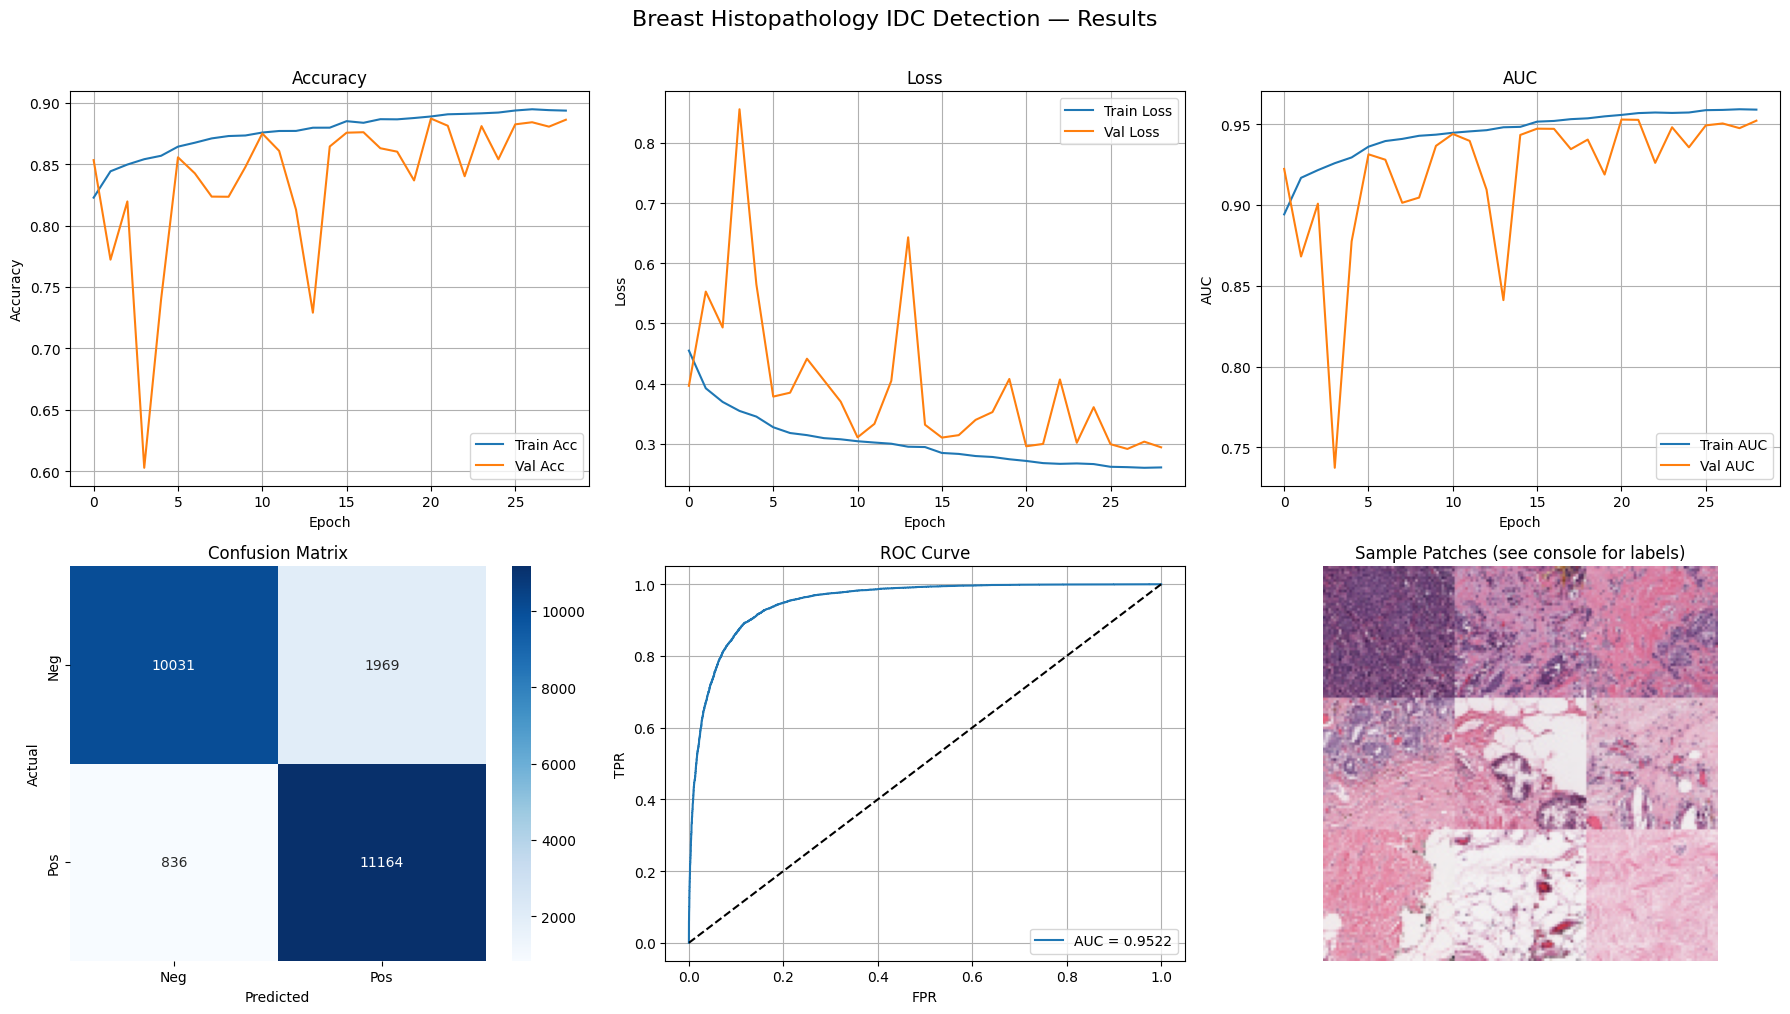

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Breast Histopathology IDC Detection — Results", fontsize=16, y=1.01)

# Accuracy curve
ax = axes[0, 0]
ax.plot(history.history["accuracy"],     label="Train Acc")
ax.plot(history.history["val_accuracy"], label="Val Acc")
ax.set_title("Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(True)

ax = axes[0, 1]
ax.plot(history.history["loss"],     label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_title("Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True)

ax = axes[0, 2]
ax.plot(history.history["auc"],     label="Train AUC")
ax.plot(history.history["val_auc"], label="Val AUC")
ax.set_title("AUC")
ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
ax.legend(); ax.grid(True)
# Confusion matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Neg", "Pos"],
            yticklabels=["Neg", "Pos"])
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score    = roc_auc_score(y_test, y_pred_prob)
ax.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
ax.plot([0, 1], [0, 1], "k--")
ax.set_title("ROC Curve")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(); ax.grid(True)

# ── Sample predictions
ax = axes[1, 2]
indices = random.sample(range(len(X_test)), 9)
grid    = np.zeros((3 * IMG_SIZE, 3 * IMG_SIZE, 3), dtype="float32")
for idx, i in enumerate(indices):
    r, c = divmod(idx, 3)
    pred_lbl = "POS" if y_pred[i] == 1 else "NEG"
    true_lbl = "POS" if y_test[i] == 1 else "NEG"
    grid[r*IMG_SIZE:(r+1)*IMG_SIZE, c*IMG_SIZE:(c+1)*IMG_SIZE] = X_test[i]
ax.imshow(grid)
ax.set_title("Sample Patches (see console for labels)")
ax.axis("off")

plt.tight_layout()
plt.savefig("idc_results.png", dpi=150, bbox_inches="tight")
print("Plots saved → idc_results.png")

2026-04-26 07:31:34.649987: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


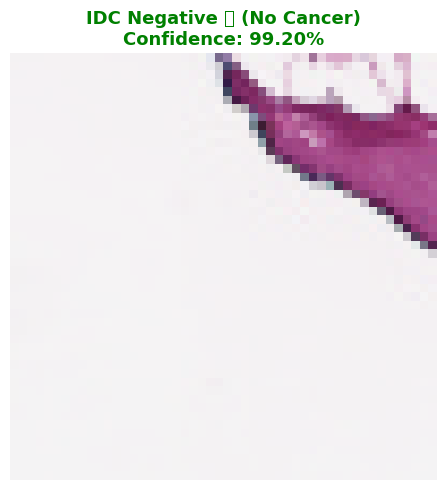


  Result     : IDC Negative 🟢 (No Cancer)
  Confidence : 99.20%
  Raw Score  : 0.0080


np.float32(0.0080358405)

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_single_image(img_path, model, img_size=50):
    """
    Predict IDC (Breast Cancer) on a single image
    """
    # Load & preprocess
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    img_normalized = img_resized.astype("float32") / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)  # shape: (1, 50, 50, 3)

    # Predict
    prob = model.predict(img_batch, verbose=0)[0][0]
    label = "IDC Positive 🔴 (Cancer)" if prob >= 0.5 else "IDC Negative 🟢 (No Cancer)"
    confidence = prob * 100 if prob >= 0.5 else (1 - prob) * 100

    # Show result
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"{label}\nConfidence: {confidence:.2f}%", 
              fontsize=13, fontweight="bold",
              color="red" if prob >= 0.5 else "green")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("single_prediction.png", dpi=150)
    plt.show()

    print(f"\n  Result     : {label}")
    print(f"  Confidence : {confidence:.2f}%")
    print(f"  Raw Score  : {prob:.4f}")

    return prob


# ── Test on ONE image (change path to your image)
img_path = X_test_p[0]   # use first test image
predict_single_image(img_path, model)

2026-04-26 07:32:00.015157: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


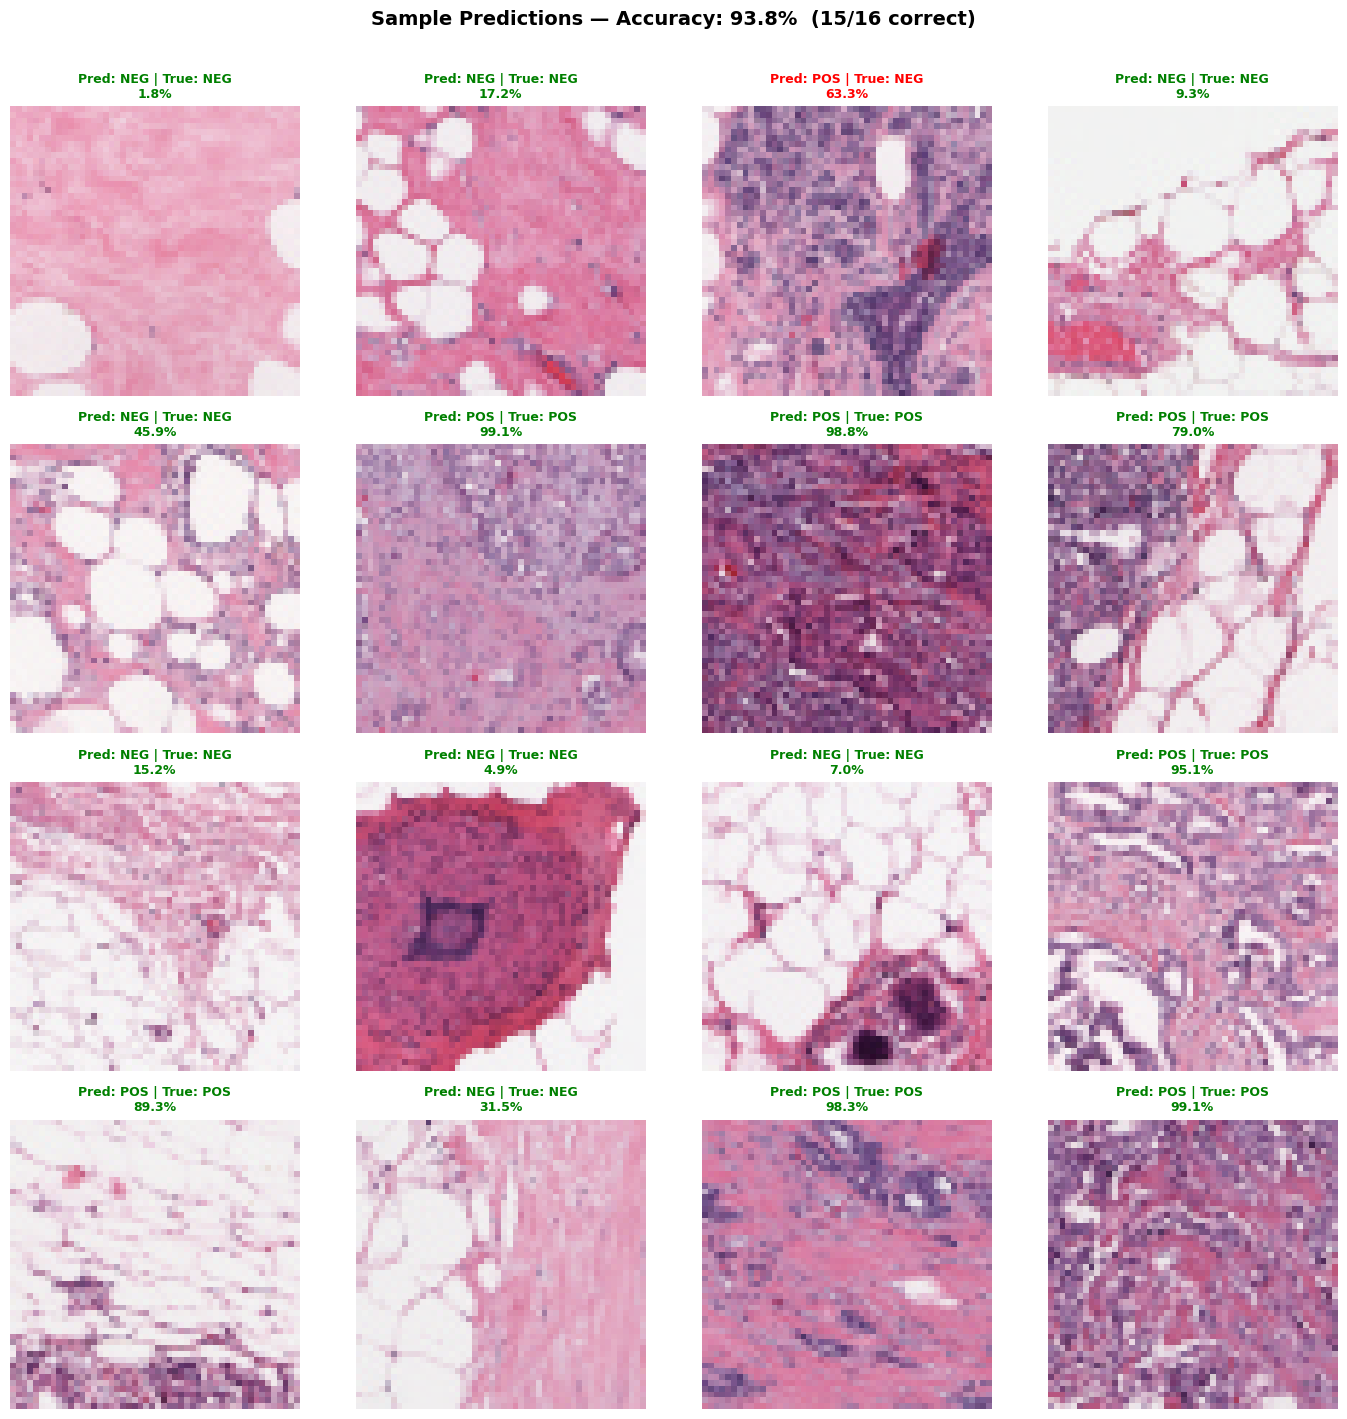


  Sample Accuracy: 93.8%  (15/16 correct)


In [35]:
def predict_multiple_images(img_paths, true_labels, model, n=16, img_size=50):
    """
    Show grid of predictions vs true labels
    """
    indices = np.random.choice(len(img_paths), n, replace=False)
    
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    correct = 0

    for i, idx in enumerate(indices):
        ax = axes[i // 4, i % 4]

        # Load & predict
        img = cv2.imread(img_paths[idx])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (img_size, img_size))
        img_norm = img_resized.astype("float32") / 255.0
        prob = model.predict(np.expand_dims(img_norm, 0), verbose=0)[0][0]

        pred = 1 if prob >= 0.5 else 0
        true = true_labels[idx]
        is_correct = pred == true
        if is_correct:
            correct += 1

        # Labels
        pred_txt = "POS" if pred == 1 else "NEG"
        true_txt = "POS" if true == 1 else "NEG"
        color = "green" if is_correct else "red"

        ax.imshow(img_resized)
        ax.set_title(f"Pred: {pred_txt} | True: {true_txt}\n{prob*100:.1f}%",
                     color=color, fontsize=9, fontweight="bold")
        ax.axis("off")

    accuracy = correct / n * 100
    plt.suptitle(f"Sample Predictions — Accuracy: {accuracy:.1f}%  ({correct}/{n} correct)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("multi_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Sample Accuracy: {accuracy:.1f}%  ({correct}/{n} correct)")


# ── Test on 16 random test images
predict_multiple_images(X_test_p, y_test, model, n=16)

In [23]:
import tensorflow as tf

# Load your saved model
model = tf.keras.models.load_model("breast_histopathology_cnn_final.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Speed optimization (recommended)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save as .tflite file
file_path = "breast_histopathology_model.tflite"
with open(file_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved: {file_path}")

INFO:tensorflow:Assets written to: /tmp/tmpk0ftm9pn/assets


INFO:tensorflow:Assets written to: /tmp/tmpk0ftm9pn/assets


Saved artifact at '/tmp/tmpk0ftm9pn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 50, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135597997680464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997680848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997681232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997682192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997682000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997681424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997681808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997681040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997680656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997683344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135597997683152: 

W0000 00:00:1777187441.717366      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777187441.717413      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777187441.746822      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [24]:
import os

print(os.listdir('/kaggle/working'))


['breast_histopathology_model.tflite', 'breast_histopathology_cnn_final.keras', 'best_idc_model.keras', 'idc_results.png', '.virtual_documents']


In [30]:
import tensorflow as tf
from google.colab import files

# Convert .keras → .tflite
model = tf.keras.models.load_model('best_idc_model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # smaller file size
tflite_model = converter.convert()

# Save it
with open('breast_histopathology_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.1f} KB")

# Download to browser
files.download('breast_histopathology_model.tflite')

INFO:tensorflow:Assets written to: /tmp/tmpstd623f4/assets


INFO:tensorflow:Assets written to: /tmp/tmpstd623f4/assets


Saved artifact at '/tmp/tmpstd623f4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 50, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135593530043152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530042576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530042192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530041232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530041424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530042000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530041616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530042384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530042768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530039888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593530040272: 

W0000 00:00:1777187909.874664      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777187909.874713      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import os

# Check the file exists and size
print(f"TFLite size: {os.path.getsize('breast_histopathology_model.tflite') / 1024:.1f} KB")

TFLite size: 1282.3 KB


In [33]:
import os

files = os.listdir('/kaggle/working/')
for f in files:
    size = os.path.getsize(f'/kaggle/working/{f}') / 1024
    print(f"  {f:45s}  {size:8.1f} KB")

  breast_histopathology_model.tflite               1282.3 KB
  breast_histopathology_cnn_final.keras           15091.7 KB
  best_idc_model.keras                            15091.7 KB
  idc_results.png                                   337.8 KB
  .virtual_documents                                  4.0 KB
  model_download.zip                             7568146.7 KB
